# Model-Level Power Analysis Smoke Test

This notebook uses the new array-backed reference layout in `data/model_power/`. The default path loads only the selected depth mean arrays and skips the CpG string index for faster simulation-oriented testing.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt

# Allows running this notebook from either the repo root or src/.
repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from analysis.model_power import (
    load_default_model_power_reference,
    prepare_template_ensemble,
    run_power_sample_size_grid,
    plot_power_by_sample_size,
)

reference_dir = repo_root / "data" / "model_power"
reference_dir

PosixPath('/dfs10/weil21-lab1/chaoronc/project/CFTK/data/model_power')

## Fast Reference Load

For the main simulation path, load only `sd_stats=["mean"]` for the depths being tested. `include_index=False` skips `cpg_index.npz` and uses row positions instead of CpG IDs.

In [2]:
depths = [10, 30]

reference = load_default_model_power_reference(
    reference_dir=reference_dir,
    depths=depths,
    sd_stats=["mean"],
    include_index=False,
    mmap_mode="r",
)

cpg_mean = reference.cpg_mean
cpg_std_summary = reference.cpg_std_summary

print("mean shape:", cpg_mean.shape)
print("std shape:", cpg_std_summary.shape)
print("std columns:", list(cpg_std_summary.columns))
print("index type:", type(cpg_mean.index).__name__)

mean shape: (3771981,)
std shape: (3771981, 2)
std columns: ['10_mean', '30_mean']
index type: RangeIndex


## Prepare Templates

In Streamlit, this should be cached as application state or with `st.cache_resource`, because templates depend on the selected reference/effect settings rather than on every button click.

In [3]:
templates = prepare_template_ensemble(
    cpg_std_summary=cpg_std_summary,
    cpg_mean=cpg_mean,
    n_templates=5,
    template_kwargs={
        "depth": depths,
        "n_features": 500,
        "n_signal_cpgs": 20,
        "meth_diff": 0.05,
        "effect_sd": 0.015,
        "effect_direction": "balanced",
        "sd_stat": "mean",
        "within_block_rho": 0.20,
        "block_size": 20,
    },
    random_state=20260617,
)

print("templates:", len(templates))
print("template features:", templates[0]["template"].metadata["n_features"])
print("template signals:", templates[0]["template"].metadata["n_signal_cpgs"])

templates: 5
template features: 500
template signals: 20


## Run A Small Grid

These settings are intentionally light for interactive testing. Increase `n_templates`, `sample_sizes`, and `simulations_per_template` for final analyses.

In [4]:
grid_result = run_power_sample_size_grid(
    templates=templates,
    sample_sizes=[50, 100, 150, 200],
    train_fraction=0.8,
    simulations_per_template=10,
    power_kwargs={
        "ratio": 1.0,
        "models": ("logreg",),
        "top_k": 10,
        "min_observed_fraction": 0.50,
        "target_auc": 0.75,
        "alpha": 0.05,
        "specificity_target": 0.90,
        "paired_depths": True,
        "logreg_params": {
            "C": 1.0,
            "solver": "liblinear",
            "max_iter": 1000,
            "class_weight": None,
        },
    },
    ci_method="none",
    n_jobs=min(4, os.cpu_count() or 1),
    random_state=20260618,
)

grid_result["power_curve"]

,sample_size,n_train,n_validation,model,depth,mean_depth,n_templates,simulations_per_template,total_simulations,mean_auc,...,detection_power_ci_high,target_attainment_probability,target_attainment_probability_ci_low,target_attainment_probability_ci_high,between_template_power_sd,template_power_q025,template_power_q975,mean_feature_recall,mean_feature_precision,ci_method
0,50,40,10,logreg,10,10,5,10,50,0.729600,...,NaN,0.52,NaN,NaN,0.311448,0.11,0.79,0.218,0.436,none
1,100,80,20,logreg,10,10,5,10,50,0.823000,...,NaN,0.76,NaN,NaN,0.134164,0.61,0.90,0.367,0.734,none
2,150,120,30,logreg,10,10,5,10,50,0.866133,...,NaN,0.84,NaN,NaN,0.194936,0.54,0.99,0.421,0.842,none
3,200,160,40,logreg,10,10,5,10,50,0.880650,...,NaN,0.98,NaN,NaN,0.044721,0.91,1.00,0.456,0.912,none
4,50,40,10,logreg,30,30,5,10,50,0.908000,...,NaN,0.92,NaN,NaN,0.260768,0.45,1.00,0.345,0.690,none
5,100,80,20,logreg,30,30,5,10,50,0.954400,...,NaN,1.00,NaN,NaN,0.000000,1.00,1.00,0.477,0.954,none
6,150,120,30,logreg,30,30,5,10,50,0.955556,...,NaN,1.00,NaN,NaN,0.000000,1.00,1.00,0.489,0.978,none
7,200,160,40,logreg,30,30,5,10,50,0.964300,...,NaN,1.00,NaN,NaN,0.000000,1.00,1.00,0.499,0.998,none


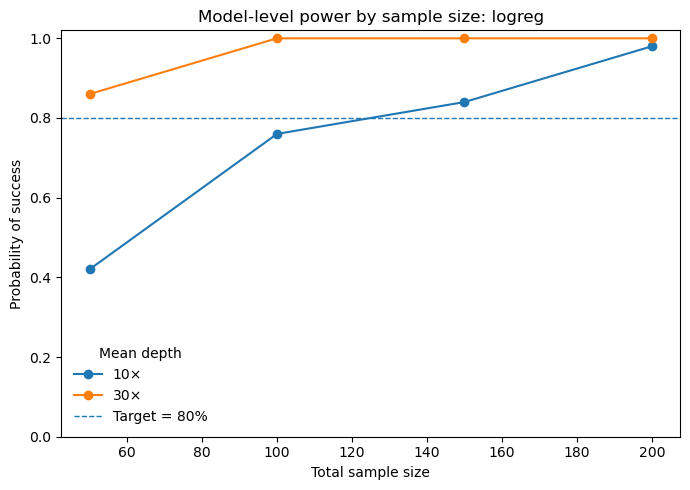

In [5]:
fig, ax = plot_power_by_sample_size(
    grid_result["power_curve"],
    model="logreg",
    power_metric="probability_of_success",
    show_ci=False,
    target_power=0.80,
)

ax.set_ylabel("Probability of success")
fig.tight_layout()
plt.show()

## Optional CI Toggle Test

This mimics a web-page CI toggle. It loads the paired per-depth CI files only when requested.

In [6]:
load_ci = False

if load_ci:
    ci_reference = load_default_model_power_reference(
        reference_dir=reference_dir,
        depths=depths,
        sd_stats=["mean", "CI_l", "CI_u"],
        include_index=False,
        mmap_mode="r",
    )
    print("CI-enabled std columns:", list(ci_reference.cpg_std_summary.columns))
else:
    print("CI loading skipped. Set load_ci = True to test CI_l/CI_u loading.")

CI loading skipped. Set load_ci = True to test CI_l/CI_u loading.


## Optional CpG ID Traceback

Simulation does not need CpG IDs. Load the index only when you need to map selected row positions back to CpG identifiers.

In [7]:
trace_cpg_ids = False

if trace_cpg_ids:
    indexed_reference = load_default_model_power_reference(
        reference_dir=reference_dir,
        depths=[10],
        sd_stats=["mean"],
        include_index=True,
        mmap_mode="r",
    )
    print(indexed_reference.cpg_mean.index[:5].tolist())
else:
    print("CpG index loading skipped. Set trace_cpg_ids = True to test ID traceback.")

CpG index loading skipped. Set trace_cpg_ids = True to test ID traceback.
